# Libraries

In [1]:
import os
import copy
import numpy as np
import pandas as pd
# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
from matplotlib import rcParams
from matplotlib import rc
from tqdm import tqdm
import wandb

# Utility Functions

* get_final_mean_accs_by_head_training_ratio(sweeps)
* get_best_final_mean_accs_by_lr(sweeps)
* get_final_mean_accs_by_drop_rate(sweeps)

In [ ]:
# forgetting from mammoth code
def forgetting(results):
    """
    Calculates the forgetting metric.

    Args:
        results (list): A list of lists representing the results of all classes of all task.

    Returns:
        float: The mean forgetting value.
    """
    n_tasks = len(results)
    li = []
    for i in range(n_tasks - 1):
        results[i] += [0.0] * (n_tasks - len(results[i]))
    np_res = np.array(results)
    maxx = np.max(np_res, axis=0)
    for i in range(n_tasks - 1):
        li.append(maxx[i] - results[-1][i])

    return np.mean(li)

# Wandb Api

In [3]:
api = wandb.Api()

# Comparison Results Table

In [4]:
from collections import defaultdict


def get_runs_grouped_by_dataset(api, project_name):
    """
    Retrieves experiment runs from Weights & Biases API and groups them by dataset name.
    """
    runs = api.runs(project_name)
    selected_runs = defaultdict(list)
    for run in runs:
        dataset = run.config['dataset']
        # Split on underscore and take first part if in {dataset}-{model_name} format
        dataset_name = dataset.split('-')[0] if '-' in dataset else dataset
        selected_runs[dataset_name].append(run)

    return selected_runs


def get_runs_selected_by_model_name(api, project_name, model_name):
    """
    Retrieves experiment runs from Weights & Biases API and groups them by dataset name.
    """
    runs = api.runs(project_name)
    selected_runs = defaultdict(list)
    for run in runs:
        if model_name == run.config['model_name']:
            dataset = run.config['dataset']
            # Split on underscore and take first part if in {dataset}-{model_name} format
            dataset_name = dataset.split('-')[0] if '-' in dataset else dataset
            selected_runs[dataset_name].append(run)

    return selected_runs

In [5]:
# Valid Set
project_name = "mmea-owcl/Experimental Results on the MMEA-OWCL (Evaluation CL & OOD)"

In [6]:
runs = api.runs(project_name)

In [7]:
len(runs)

319

In [8]:
selected_runs = get_runs_grouped_by_dataset(api, project_name)

In [9]:
selected_runs.keys()

dict_keys(['mmea'])

In [52]:
tbn_replay_runs = get_runs_selected_by_model_name(api, project_name, model_name='tbn_replay')
tbn_icarl_runs = get_runs_selected_by_model_name(api, project_name, model_name='tbn_icarl')

In [53]:
for k, v in tbn_replay_runs.items():
    print("Dataset: {}, Number of runs: {}".format(k.upper(), len(v)))
    
for k, v in tbn_icarl_runs.items():
    print("Dataset: {}, Number of runs: {}".format(k.upper(), len(v)))

Dataset: MMEA, Number of runs: 80
Dataset: MMEA, Number of runs: 81


Example run

In [12]:
run = tbn_replay_runs['mmea'][0]

In [13]:
[k for k in run.summary.keys() if 'auroc' in k]

['Task/Energy_auroc',
 'Task/LTS_Acce_Only_auroc',
 'Task/LTS_Fusion_auroc',
 'Task/LTS_Gyro_Only_auroc',
 'Task/LTS_Individual_auroc',
 'Task/LTS_Late_Fusion_auroc',
 'Task/LTS_RGB_Only_auroc',
 'Task/MSP_auroc',
 'Task/ODIN_auroc']

In [14]:
[k for k in run.summary.keys() if 'acc' in k]

['Task/avg_acc']

In [15]:
run.config

{'lr': 0.001,
 'arch': 'BNInception',
 'host': 'ee60c5c7682d',
 'mode': 'eval',
 'seed': 1997,
 'device': [0],
 'epochs': 50,
 'freeze': False,
 'prefix': 'mmea-owcl',
 'run_id': 'eac33436',
 'dataset': 'mmea-tbn',
 'dropout': 0.5,
 'shuffle': False,
 'workers': 4,
 'backbone': 'tbn',
 'gpu_name': 'NVIDIA GeForce RTX 3090',
 'init_cls': 8,
 'lr_steps': [10, 20],
 'modality': ['RGB', 'Gyro', 'Acce'],
 'momentum': 0.9,
 'mpu_path': './datasets/UESTC-MMEA-CL/UESTC-MMEA-CL/mpu/',
 'increment': 8,
 'partialbn': True,
 'test_list': 'mydataset_test.txt',
 'timestamp': '2025-09-08 09:27:18.223413',
 'use_wandb': True,
 'batch_size': 8,
 'debug_mode': False,
 'enable_ood': True,
 'model_name': 'tbn_replay',
 'train_list': 'mydataset_total_train.txt',
 'fusion_type': 'concat',
 'memory_size': 320,
 'ood_methods': ['MSP',
  'ODIN',
  'Energy',
  'LTS_Individual',
  'LTS_Fusion',
  'LTS_RGB_Only',
  'LTS_Gyro_Only',
  'LTS_Acce_Only',
  'LTS_Late_Fusion'],
 'log_test_acc': False,
 'num_segments': 

In [16]:
history = run.history(keys=["Task/Energy_auroc"])
history

,_step,Task/Energy_auroc
0,3,89.343124
1,13,86.726199
2,23,81.198381


각 Metric의 결과값을 Task 뱔러 가져오기.

In [62]:
common_columns = [
    'model_name', 'modality', 'increment', 'seed', 'lr', 'gpu_name'
]
metric_columns = [
    'Task/avg_acc', 
    'Task/Energy_auroc',
    'Task/LTS_Acce_Only_auroc',
    'Task/LTS_Fusion_auroc',
    'Task/LTS_Individual_auroc',
    'Task/MSP_auroc',
    'Task/ODIN_auroc'
]

def get_history_by_metric(run, metric_columns):
    # Get all available metrics from summary
    available_metrics = [k for k in run.summary.keys() if k in metric_columns]
    # print("Available metrics in summary:", available_metrics)
    
    # Get history for each available metric separately and concatenate
    history_dfs = pd.DataFrame()
    for metric in available_metrics:
        metric_history = run.history(keys=[metric])
        if not metric_history.empty:
            history_dfs = pd.concat([history_dfs, metric_history], axis=1)
    
    # Drop the _step column if it exists and history_dfs is not empty
    if not history_dfs.empty and '_step' in history_dfs.columns:
        history_dfs = history_dfs.drop(columns=['_step'])
    
    # Add Task_id column
    history_dfs['Task_id'] = [i+1 for i in range(len(history_dfs))]
    
    return history_dfs


def rename_column(metric_col, task_col):
    # Apply the function to each row
    def _rename_single(metric, task):
        t, n = metric.split('/')
        # Change Task to Task{task_number}
        t = t + str(task)
        return t + '/' + n
    
    # Apply rename function to each row using vectorized operations
    return [_rename_single(m, t) for m, t in zip(metric_col, task_col)]


def melt_and_rename_history_dfs(history_dfs):
    history_dfs_melted = history_dfs.melt(id_vars=['Task_id'])
    history_dfs_melted.columns = ['Task_id', 'Metrics', 'score']
    history_dfs_melted.dropna(inplace=True)
    
    # Apply the function to create new column names
    # history_dfs_melted['Task_id/Metrics'] = rename_column(
    #     history_dfs_melted['Metrics'], 
    #     history_dfs_melted['Task_id']
    # )

    return history_dfs_melted


In [18]:
history_dfs = get_history_by_metric(run, metric_columns)

Available metrics in summary: ['Task/Energy_auroc', 'Task/LTS_Acce_Only_auroc', 'Task/LTS_Fusion_auroc', 'Task/LTS_Individual_auroc', 'Task/MSP_auroc', 'Task/ODIN_auroc', 'Task/avg_acc']


In [19]:
history_dfs

,Task/Energy_auroc,Task/LTS_Acce_Only_auroc,Task/LTS_Fusion_auroc,Task/LTS_Individual_auroc,Task/MSP_auroc,Task/ODIN_auroc,Task/avg_acc,Task_id
0,89.343124,89.400136,89.609283,89.279296,89.021813,88.293673,97.85,1
1,86.726199,86.729202,86.582526,86.750915,88.396569,87.412457,95.48,2
2,81.198381,81.206111,80.522444,81.150762,75.298467,68.373515,89.38,3
3,NaN,NaN,NaN,NaN,NaN,NaN,84.73,4


In [20]:
history_dfs = melt_and_rename_history_dfs(history_dfs)
history_dfs.head(10)

,Task_id,Metrics,score
0,1,Task/Energy_auroc,89.343124
1,2,Task/Energy_auroc,86.726199
2,3,Task/Energy_auroc,81.198381
4,1,Task/LTS_Acce_Only_auroc,89.400136
5,2,Task/LTS_Acce_Only_auroc,86.729202
6,3,Task/LTS_Acce_Only_auroc,81.206111
8,1,Task/LTS_Fusion_auroc,89.609283
9,2,Task/LTS_Fusion_auroc,86.582526
10,3,Task/LTS_Fusion_auroc,80.522444
12,1,Task/LTS_Individual_auroc,89.279296


In [21]:
for col in common_columns:
    print(run.config.get(col))

tbn_replay
['RGB', 'Gyro', 'Acce']
8
1997
0.001
NVIDIA GeForce RTX 3090


In [22]:
metric_columns[1]

'Task/Energy_auroc'

In [23]:
metric_columns

['Task/avg_acc',
 'Task/Energy_auroc',
 'Task/LTS_Acce_Only_auroc',
 'Task/LTS_Fusion_auroc',
 'Task/LTS_Individual_auroc',
 'Task/MSP_auroc',
 'Task/ODIN_auroc']

In [64]:
# result_replay_df = pd.DataFrame()
# for dataset, runs in tbn_replay_runs.items():
#     for run in tqdm(runs):
#         history_dfs = get_history_by_metric(run, metric_columns)
#         history_dfs = melt_and_rename_history_dfs(history_dfs)
#         # set common columns
#         history_dfs['dataset'] = dataset
#         for col in common_columns:
#             value = run.config.get(col)
#             if isinstance(value, list):
#                 value = str(value)
#             history_dfs[col] = value
                
#         result_replay_df = pd.concat([result_replay_df, history_dfs], ignore_index=True)
        
def get_result_df(model_runs):
    result_df = pd.DataFrame()
    
    for dataset, runs in model_runs.items():
        print("Dataset: {}".format(dataset.upper()))
        
        bpar = tqdm(runs)
        for run in bpar:
            try:
                history_dfs = get_history_by_metric(run, metric_columns)
                history_dfs = melt_and_rename_history_dfs(history_dfs)
                # set common columns 
                history_dfs['dataset'] = dataset
                for col in common_columns:
                    value = run.config.get(col)
                    if isinstance(value, list):
                        value = str(value)
                    history_dfs[col] = value
                
                result_df = pd.concat([result_df, history_dfs], ignore_index=True)
                
                bpar.set_description("Processing: {}".format(dataset.upper()))
                
            except Exception as e:
                print(f"Error processing run for dataset {dataset}: {str(e)}")
                continue
            
    return result_df

In [ ]:
result_replay_df = get_result_df(tbn_replay_runs)
result_icarl_df = get_result_df(tbn_icarl_runs)

Dataset: MMEA


Processing: MMEA:  57%|█████▊    | 46/80 [02:12<01:44,  3.09s/it]

In [59]:
result_replay_df.to_csv('result_replay_df.csv', index=False)
result_icarl_df.to_csv('result_icarl_df.csv', index=False)

In [60]:
result_replay_df = pd.read_csv('result_replay_df.csv')
result_icarl_df = pd.read_csv('result_icarl_df.csv')

In [ ]:
replay_inc2_df = result_replay_df.query("increment == 2")
replay_inc4_df = result_replay_df.query("increment == 4")
replay_inc8_df = result_replay_df.query("increment == 8 and seed == 1993")

icarl_inc2_df = result_icarl_df.query("increment == 2")
icarl_inc4_df = result_icarl_df.query("increment == 4")
icarl_inc8_df = result_icarl_df.query("increment == 8 and seed == 1993")

In [ ]:
replay_inc4_df.groupby(['Task_id', 'Metrics', 'modality']).count()

score  dataset  model_name  \
Task_id Metrics           modality                                              
1.0     Task/Energy_auroc ['Acce']                     5        5           5   
                          ['Gyro']                     5        5           5   
                          ['RGB', 'Gyro', 'Acce']      5        5           5   
                          ['RGB', 'Gyro']              5        5           5   
                          ['RGB']                      5        5           5   
...                                                  ...      ...         ...   
8.0     Task/avg_acc      ['Acce']                     5        5           5   
                          ['Gyro']                     5        5           5   
                          ['RGB', 'Gyro', 'Acce']      5        5           5   
                          ['RGB', 'Gyro']              5        5           5   
                          ['RGB']                      5        5           5   

                                                   increment  seed  lr  \
Task_id Metrics           modality                                       
1.0     Task/Energy_auroc ['Acce']                         5     5   5   
                          ['Gyro']                         5     5   5   
                          ['RGB', 'Gyro', 'Acce']          5     5   5   
                          ['RGB', 'Gyro']                  5     5   5   
                          ['RGB']                          5     5   5   
...                                                      ...   ...  ..   
8.0     Task/avg_acc      ['Acce']                         5     5   5   
                          ['Gyro']                         5     5   5   
                          ['RGB', 'Gyro', 'Acce']          5     5   5   
                          ['RGB', 'Gyro']                  5     5   5   
                          ['RGB']                          5     5   5   

                                                   gpu_name  
Task_id Metrics           modality                           
1.0     Task/Energy_auroc ['Acce']                        5  
                          ['Gyro']                        5  
                          ['RGB', 'Gyro', 'Acce']         5  
                          ['RGB', 'Gyro']                 5  
                          ['RGB']                         5  
...                                                     ...  
8.0     Task/avg_acc      ['Acce']                        5  
                          ['Gyro']                        5  
                          ['RGB', 'Gyro', 'Acce']         5  
                          ['RGB', 'Gyro']                 5  
                          ['RGB']                         5  

[229 rows x 7 columns]

In [27]:
inc8_df.Metrics.unique()

array(['Task/Energy_auroc', 'Task/LTS_Acce_Only_auroc',
       'Task/LTS_Fusion_auroc', 'Task/LTS_Individual_auroc',
       'Task/MSP_auroc', 'Task/ODIN_auroc', 'Task/avg_acc'], dtype=object)

In [44]:
inc8_df.query("Metrics == 'Task/Energy_auroc'").groupby(by=['modality', 'Task_id', 'Metrics']).count()
inc4_df.query("Metrics == 'Task/Energy_auroc'").groupby(by=['modality', 'Task_id', 'Metrics']).count()

score  dataset  model_name  \
modality                Task_id Metrics                                         
['Acce']                1.0     Task/Energy_auroc      5        5           5   
                        2.0     Task/Energy_auroc      5        5           5   
                        3.0     Task/Energy_auroc      5        5           5   
                        4.0     Task/Energy_auroc      5        5           5   
                        5.0     Task/Energy_auroc      5        5           5   
                        6.0     Task/Energy_auroc      5        5           5   
                        7.0     Task/Energy_auroc      5        5           5   
['Gyro']                1.0     Task/Energy_auroc      5        5           5   
                        2.0     Task/Energy_auroc      5        5           5   
                        3.0     Task/Energy_auroc      5        5           5   
                        4.0     Task/Energy_auroc      5        5           5   
                        5.0     Task/Energy_auroc      5        5           5   
                        6.0     Task/Energy_auroc      5        5           5   
                        7.0     Task/Energy_auroc      5        5           5   
['RGB', 'Gyro', 'Acce'] 1.0     Task/Energy_auroc      5        5           5   
                        2.0     Task/Energy_auroc      5        5           5   
                        3.0     Task/Energy_auroc      5        5           5   
                        4.0     Task/Energy_auroc      5        5           5   
                        5.0     Task/Energy_auroc      5        5           5   
                        6.0     Task/Energy_auroc      5        5           5   
                        7.0     Task/Energy_auroc      5        5           5   
['RGB', 'Gyro']         1.0     Task/Energy_auroc      5        5           5   
                        2.0     Task/Energy_auroc      5        5           5   
                        3.0     Task/Energy_auroc      5        5           5   
                        4.0     Task/Energy_auroc      5        5           5   
                        5.0     Task/Energy_auroc      5        5           5   
                        6.0     Task/Energy_auroc      5        5           5   
                        7.0     Task/Energy_auroc      5        5           5   
['RGB']                 1.0     Task/Energy_auroc      5        5           5   
                        2.0     Task/Energy_auroc      5        5           5   
                        3.0     Task/Energy_auroc      5        5           5   
                        4.0     Task/Energy_auroc      5        5           5   
                        5.0     Task/Energy_auroc      5        5           5   
                        6.0     Task/Energy_auroc      5        5           5   
                        7.0     Task/Energy_auroc      5        5           5   

                                                   increment  seed  lr  \
modality                Task_id Metrics                                  
['Acce']                1.0     Task/Energy_auroc          5     5   5   
                        2.0     Task/Energy_auroc          5     5   5   
                        3.0     Task/Energy_auroc          5     5   5   
                        4.0     Task/Energy_auroc          5     5   5   
                        5.0     Task/Energy_auroc          5     5   5   
                        6.0     Task/Energy_auroc          5     5   5   
                        7.0     Task/Energy_auroc          5     5   5   
['Gyro']                1.0     Task/Energy_auroc          5     5   5   
                        2.0     Task/Energy_auroc          5     5   5   
                        3.0     Task/Energy_auroc          5     5   5   
                        4.0     Task/Energy_auroc          5     5   5   
                        5.0     Task/Energy_auroc          5     5   5   
                 

In [49]:
tmp_df = inc8_df.query("Metrics == 'Task/Energy_auroc'")

df_inc8_summary = (
    tmp_df.groupby(by=['modality', 'Task_id'])
    .agg({
        'score': ['mean']
    })
    .reset_index()
)

tmp_df = inc4_df.query("Metrics == 'Task/Energy_auroc'")

df_inc4_summary = (
    tmp_df.groupby(by=['modality', 'Task_id'])
    .agg({
        'score': ['mean']
    })
    .reset_index()
)

df_inc4_summary.columns = ['modality', 'Task_id', 'Energy AUROC']
df_inc8_summary.columns = ['modality', 'Task_id', 'Energy AUROC']

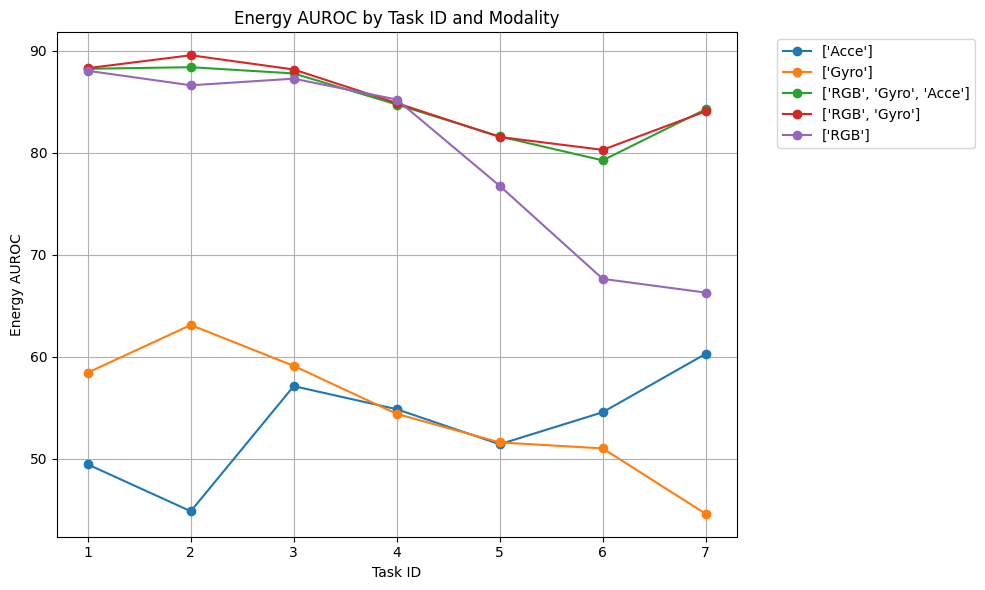

In [50]:
# Create line plot showing Energy AUROC by Task_id for each modality
plt.figure(figsize=(10, 6))

# Plot each modality as a separate line
for modality in df_inc4_summary['modality'].unique():
    data = df_inc4_summary[df_inc4_summary['modality'] == modality]
    plt.plot(data['Task_id'], data['Energy AUROC'], marker='o', label=modality)

plt.xlabel('Task ID')
plt.ylabel('Energy AUROC')
plt.title('Energy AUROC by Task ID and Modality')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

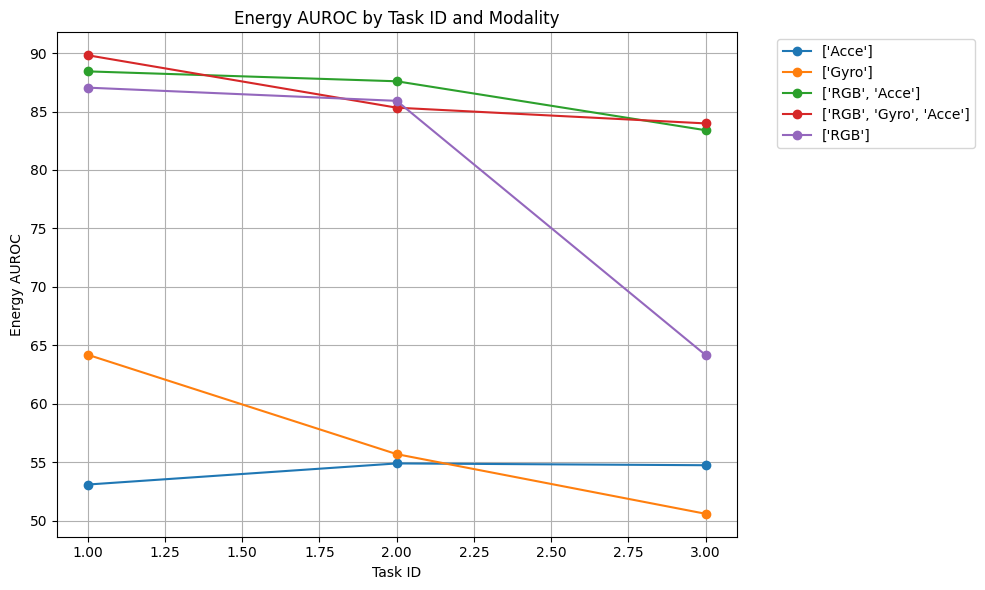

In [51]:
# Create line plot showing Energy AUROC by Task_id for each modality
plt.figure(figsize=(10, 6))

# Plot each modality as a separate line
for modality in df_inc8_summary['modality'].unique():
    data = df_inc8_summary[df_inc8_summary['modality'] == modality]
    plt.plot(data['Task_id'], data['Energy AUROC'], marker='o', label=modality)

plt.xlabel('Task ID')
plt.ylabel('Energy AUROC')
plt.title('Energy AUROC by Task ID and Modality')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

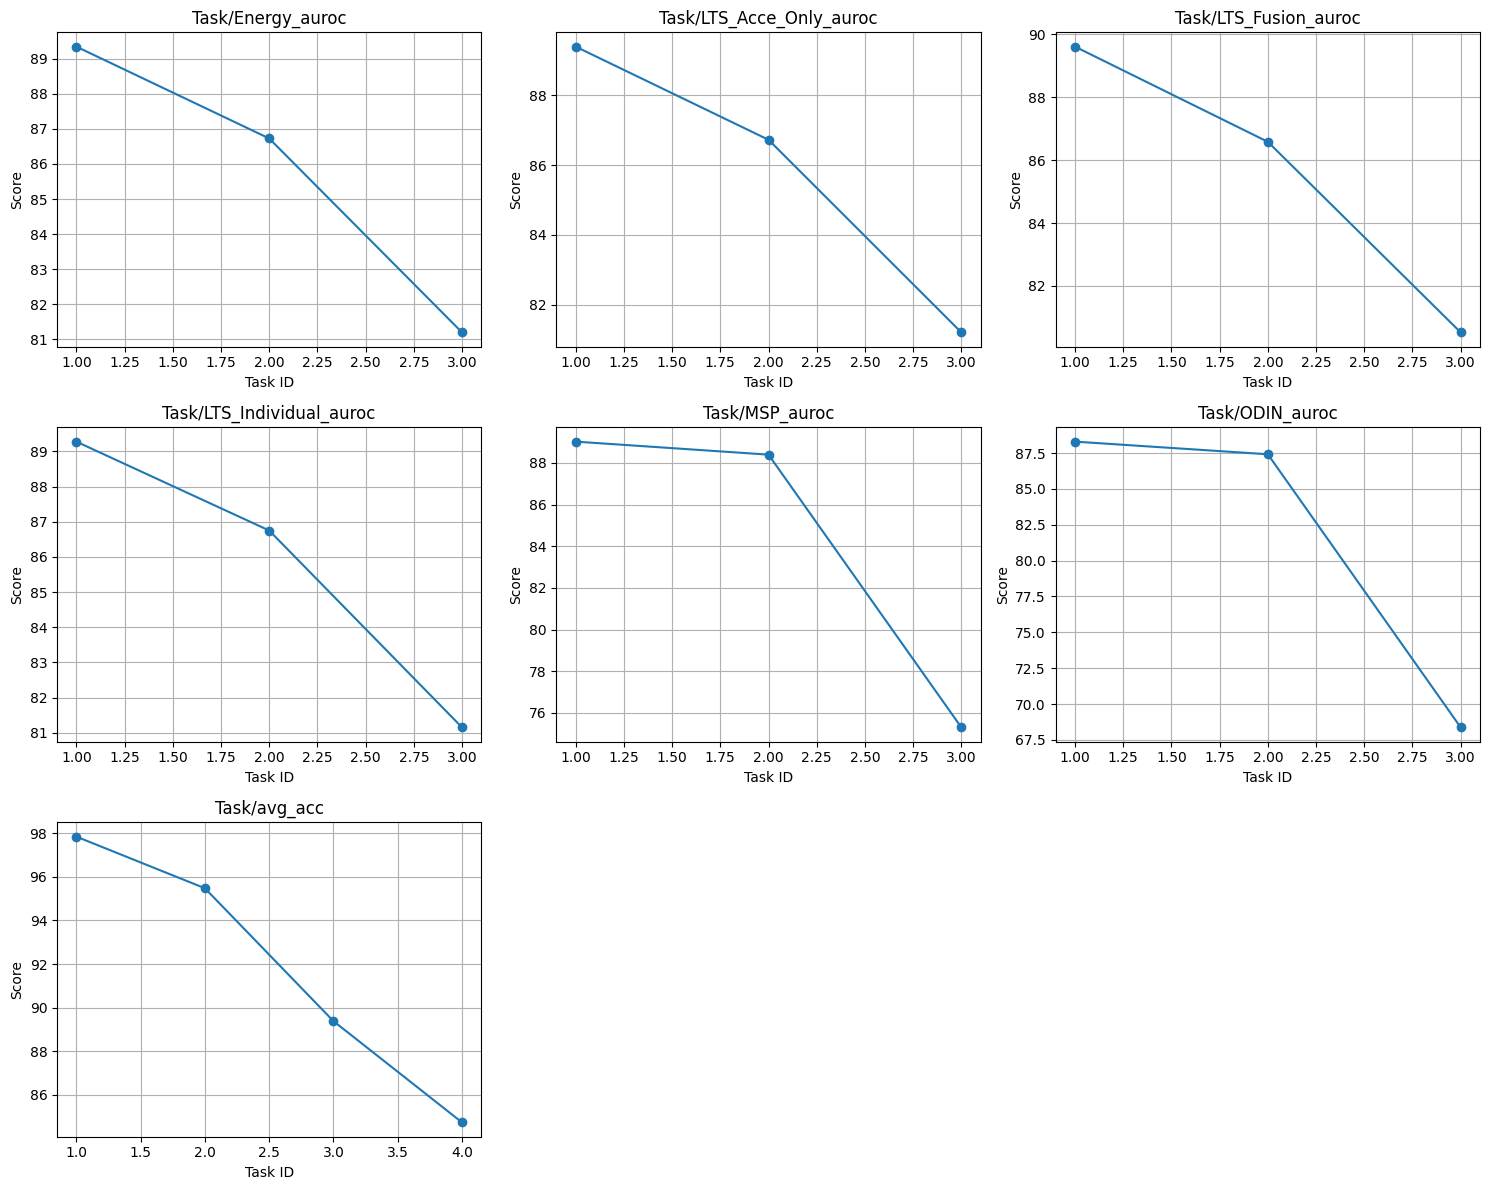

In [244]:
# visualize Metrics by Task id
import matplotlib.pyplot as plt

# Get unique metrics
metrics = history_dfs_restored['Metrics'].unique()

# Calculate number of rows and columns for subplots
n_metrics = len(metrics)
n_cols = 3
n_rows = (n_metrics + n_cols - 1) // n_cols

# Create figure and subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

# Plot each metric in its own subplot
for i, metric in enumerate(metrics):
    data = history_dfs_restored[history_dfs_restored['Metrics'] == metric]
    axes[i].plot(data['Task_id'], data['score'], marker='o')
    axes[i].set_xlabel('Task ID')
    axes[i].set_ylabel('Score')
    axes[i].set_title(metric)
    axes[i].grid(True)

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
